In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("antobenedetti/animals")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'animals' dataset.
Path to dataset files: /kaggle/input/animals
Contents of base_path (/kaggle/input):
['animals']
Contents of path (/kaggle/input/animals):
['animals']


In [ ]:
import os

dataset_dir = os.path.join(path, 'animals')
sub_folders = ['train', 'val', 'inf']

for folder in sub_folders:
    folder_path = os.path.join(dataset_dir, folder)
    if os.path.exists(folder_path):
        animal_classes = [d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))]
        print(f"Folder '{folder}' contains {len(animal_classes)} animal classes.")
        print(f"Example classes: {animal_classes[:5]}\n")

Folder 'train' contains 5 animal classes.
Example classes: ['horse', 'lion', 'dog', 'elephant', 'cat']

Folder 'val' contains 5 animal classes.
Example classes: ['horse', 'lion', 'dog', 'elephant', 'cat']

Folder 'inf' contains 0 animal classes.
Example classes: []



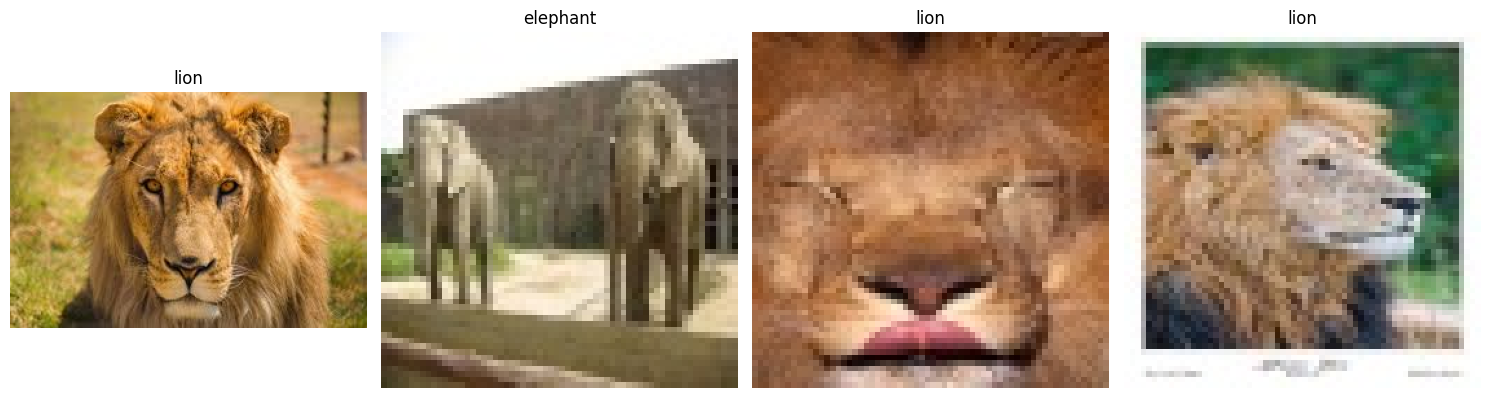

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

plt.figure(figsize=(15, 10))

train_dir = os.path.join(dataset_dir, 'train')
animal_types = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

for i in range(4):
    selected_animal = random.choice(animal_types)
    animal_folder = os.path.join(train_dir, selected_animal)
    images = [f for f in os.listdir(animal_folder) if os.path.isfile(os.path.join(animal_folder, f))]

    if images:
        random_img = random.choice(images)
        img_path = os.path.join(animal_folder, random_img)
        img = mpimg.imread(img_path)
        plt.subplot(1, 4, i + 1)
        plt.imshow(img)
        plt.title(selected_animal)
        plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf

# Check GPU availability
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU is available: {gpu_devices}")
    # Setting memory growth to avoid allocating all memory at once
    for gpu in gpu_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("GPU is not available. Training will be slow on CPU.")

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

# Data Preparation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(dataset_dir, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Model Building
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers for transfer learning

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Found 13474 images belonging to 5 classes.
Found 1497 images belonging to 5 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 287s 646ms/step - accuracy: 0.2415 - loss: 1.6017 - val_accuracy: 0.3761 - val_loss: 1.5134
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 204s 482ms/step - accuracy: 0.2872 - loss: 1.5637 - val_accuracy: 0.3901 - val_loss: 1.4697
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 201s 476ms/step - accuracy: 0.2923 - loss: 1.5475 - val_accuracy: 0.4342 - val_loss: 1.4282
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 199s 471ms/step - accuracy: 0.3034 - loss: 1.5348 - val_accuracy: 0.4649 - val_loss: 1.3698
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 202s 478ms/step - accuracy: 0.3204 - loss: 1.5171 - val_accuracy: 0.5244 - val_loss: 1.3584
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 199s 472ms/step - accuracy: 0.3348 - loss: 1.4947 - val_accuracy: 0.5464 - val_loss: 1.2909
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 200s 475ms/step - accuracy: 0.34

In [ ]:
# Summary of training results
loss, accuracy = model.evaluate(val_generator)
print(f"Final Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.4990 - loss: 1.2492
Final Validation Loss: 1.2492
Final Validation Accuracy: 0.4990


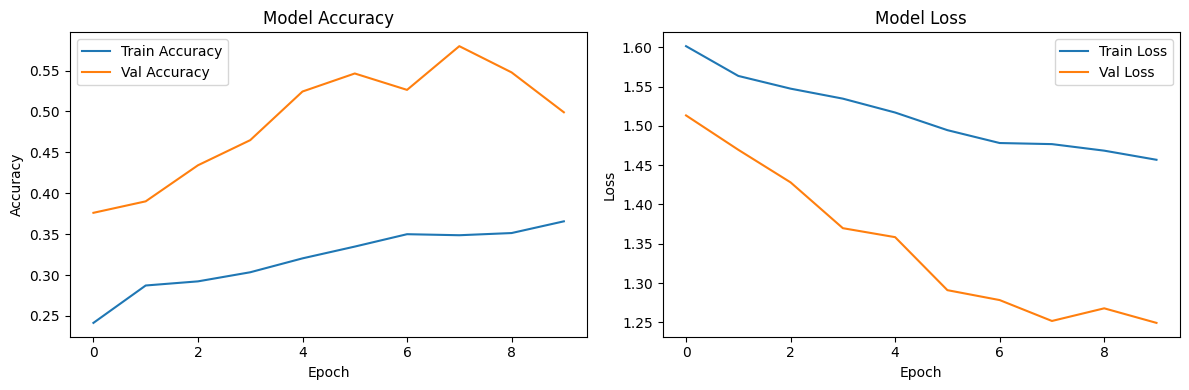

In [ ]:
# Visualization of training metrics
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()